# CH 5 - 5 : THE QUESTION - IS THE TEST STATISTIC IMPROBABLE?

## Objectif pédagogique

Ce cahier explique le cœur logique du test d'hypothèse appliqué au trading EBTA :

> **Le profit observé est-il assez rare sous l'hypothèse que la règle n'a aucun talent ?**

Autrement dit, on ne demande pas simplement :

> “Est-ce que la stratégie a gagné ?”

On demande plutôt :

> “Quelle est la probabilité qu'une stratégie sans edge obtienne un résultat au moins aussi bon par simple chance ?”

C'est cette probabilité qui correspond à la **p-value**.


## 1. L'idée centrale

Dans un backtest, un profit peut venir de deux sources :

1. **La chance** : la règle n'a aucun pouvoir prédictif, mais elle a profité d'une fluctuation favorable.
2. **Le talent / edge** : la règle exploite réellement une inefficience ou un comportement récurrent du marché.

Le test d'hypothèse commence volontairement par une position sceptique :

- $H_0$ : la règle n'a aucun talent, son rendement moyen réel est nul ou inférieur à zéro.
- $H_A$ : la règle a un talent, son rendement moyen réel est supérieur à zéro.

La question devient donc :

> Si $H_0$ était vraie, est-ce que le rendement observé serait courant ou extrêmement rare ?


## 2. Analogie trading

Imagine deux traders :

- **Trader A** gagne +0,02 % par jour sur 20 jours.
- **Trader B** gagne +0,02 % par jour sur 2 000 jours.

Le rendement moyen est identique, mais la preuve n'a pas la même force.

Pourquoi ?

Parce qu'avec peu d'observations, la chance peut facilement produire un bon résultat.  
Avec beaucoup d'observations, il devient beaucoup plus difficile d'expliquer le même résultat par le hasard.

C'est le rôle de la **distribution d'échantillonnage** :

- elle est large quand il y a peu de données ou beaucoup de volatilité ;
- elle est étroite quand il y a beaucoup de données ou peu de volatilité.


## 3. Importation des bibliothèques

Nous allons simuler des rendements de stratégie sous $H_0$, c'est-à-dire une stratégie sans edge.

Sous $H_0$ :

$$
\mu = 0
$$

La moyenne réelle de la stratégie est zéro. Les profits observés ne viennent donc que du bruit statistique.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 4. Créer une distribution de la chance

On suppose que la règle de trading n'a aucun talent.

Elle produit des rendements journaliers centrés autour de zéro, avec une certaine volatilité.

Ensuite, on simule plusieurs milliers de backtests possibles sous cette hypothèse nulle.


In [2]:
# Paramètres de simulation
n_days = 250          # nombre de jours dans un backtest
daily_vol = 0.01      # volatilité journalière de 1 %
n_simulations = 20_000

# Sous H0, la vraie moyenne est 0
returns_under_h0 = np.random.normal(
    loc=0,
    scale=daily_vol,
    size=(n_simulations, n_days)
)

# Statistique de test : moyenne des rendements journaliers du backtest
sample_means = returns_under_h0.mean(axis=1)

pd.Series(sample_means).describe()

count    20000.000000
mean        -0.000002
std          0.000626
min         -0.002459
25%         -0.000424
50%         -0.000005
75%          0.000421
max          0.002413
dtype: float64

## 5. Visualiser la distribution d'échantillonnage

Cette courbe représente ce que la chance seule peut produire.

Si le rendement moyen observé dans ton backtest tombe au centre de cette courbe, il n'est pas surprenant.  
Si le rendement tombe très loin dans la queue droite, il devient difficile de dire : “c'est juste de la chance”.


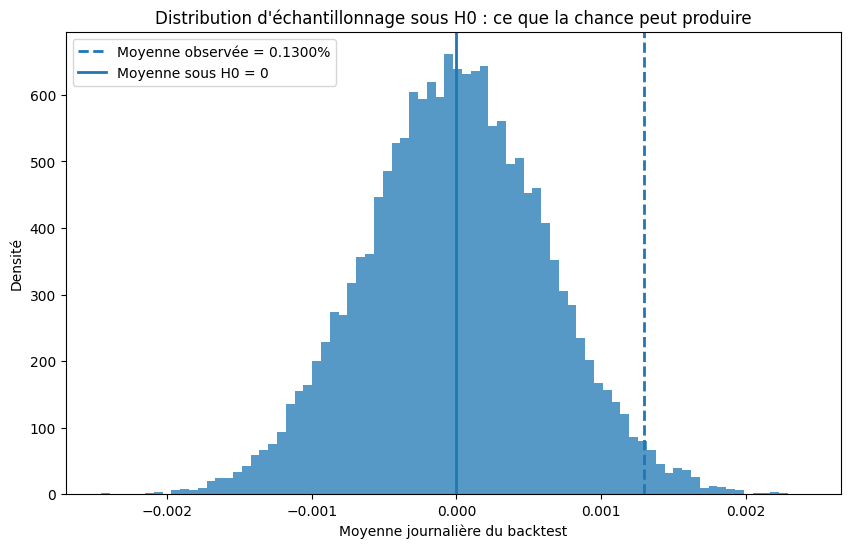

In [3]:
observed_mean = 0.0013  # exemple : +0,13 % par jour

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=80, density=True, alpha=0.75)
plt.axvline(observed_mean, linestyle="--", linewidth=2, label=f"Moyenne observée = {observed_mean:.4%}")
plt.axvline(0, linestyle="-", linewidth=2, label="Moyenne sous H0 = 0")
plt.title("Distribution d'échantillonnage sous H0 : ce que la chance peut produire")
plt.xlabel("Moyenne journalière du backtest")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 6. Calculer la p-value

La p-value répond à la question :

> Si la règle n'avait aucun talent, quelle serait la probabilité d'obtenir une moyenne au moins aussi élevée que celle observée ?

Pour un test unilatéral à droite :

$$
p\text{-value} = P(\bar{R} \geq \bar{R}_{observé} \mid H_0)
$$


In [4]:
p_value = np.mean(sample_means >= observed_mean)

print(f"Moyenne observée : {observed_mean:.4%}")
print(f"p-value : {p_value:.4f}")

if p_value < 0.05:
    print("Décision : on rejette H0 au seuil de 5 %. Le résultat est jugé statistiquement rare.")
else:
    print("Décision : on ne rejette pas H0. Le résultat peut encore être expliqué par la chance.")

Moyenne observée : 0.1300%
p-value : 0.0198
Décision : on rejette H0 au seuil de 5 %. Le résultat est jugé statistiquement rare.


## 7. Zone de rareté : seuil de 5 %

On peut représenter le seuil critique.

Si le résultat observé est au-delà du 95e percentile de la distribution sous $H_0$, il se trouve dans la zone des résultats rares.


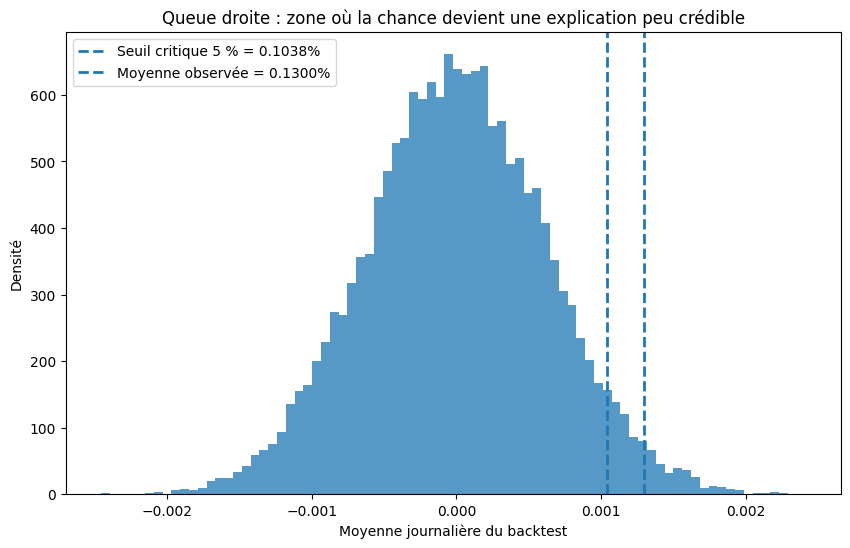

Seuil critique à 5 % : 0.1038%
Moyenne observée : 0.1300%


In [5]:
critical_value = np.quantile(sample_means, 0.95)

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=80, density=True, alpha=0.75)
plt.axvline(critical_value, linestyle="--", linewidth=2, label=f"Seuil critique 5 % = {critical_value:.4%}")
plt.axvline(observed_mean, linestyle="--", linewidth=2, label=f"Moyenne observée = {observed_mean:.4%}")
plt.title("Queue droite : zone où la chance devient une explication peu crédible")
plt.xlabel("Moyenne journalière du backtest")
plt.ylabel("Densité")
plt.legend()
plt.show()

print(f"Seuil critique à 5 % : {critical_value:.4%}")
print(f"Moyenne observée : {observed_mean:.4%}")

## 8. Pourquoi la largeur de la distribution compte

La même performance peut être :

- impressionnante si la distribution de la chance est étroite ;
- banale si la distribution de la chance est large.

La largeur dépend surtout de deux facteurs :

1. **La volatilité des rendements**  
   Plus les rendements sont volatils, plus la chance peut produire des résultats extrêmes.

2. **La taille de l'échantillon**  
   Plus il y a de trades ou de jours, plus la moyenne devient stable.


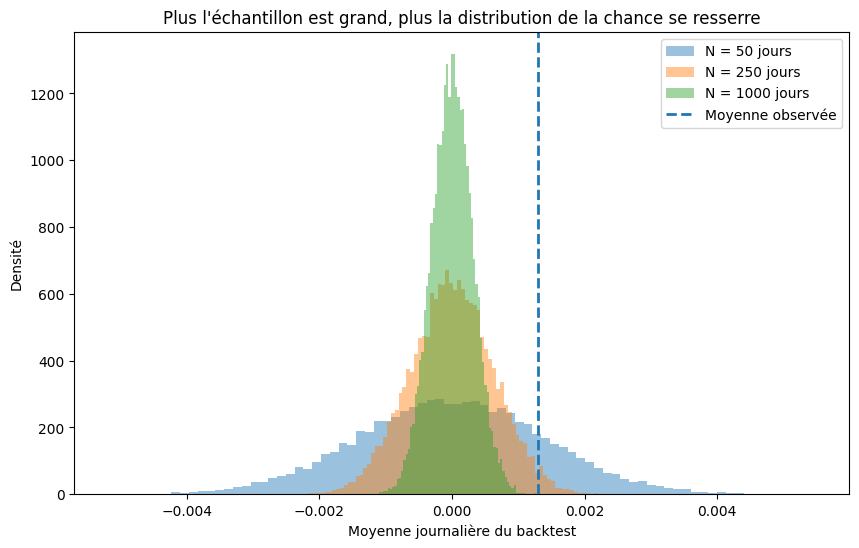

In [6]:
def simulate_sampling_distribution(n_days, daily_vol=0.01, n_simulations=20_000):
    data = np.random.normal(0, daily_vol, size=(n_simulations, n_days))
    return data.mean(axis=1)

sample_means_50 = simulate_sampling_distribution(n_days=50)
sample_means_250 = simulate_sampling_distribution(n_days=250)
sample_means_1000 = simulate_sampling_distribution(n_days=1000)

plt.figure(figsize=(10, 6))
plt.hist(sample_means_50, bins=80, density=True, alpha=0.45, label="N = 50 jours")
plt.hist(sample_means_250, bins=80, density=True, alpha=0.45, label="N = 250 jours")
plt.hist(sample_means_1000, bins=80, density=True, alpha=0.45, label="N = 1000 jours")
plt.axvline(observed_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.title("Plus l'échantillon est grand, plus la distribution de la chance se resserre")
plt.xlabel("Moyenne journalière du backtest")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 9. Effet de la volatilité

À taille d'échantillon identique, une stratégie très volatile rend la preuve statistique plus difficile.

Pourquoi ?

Parce que la chance seule peut produire de grands écarts quand la variance est élevée.


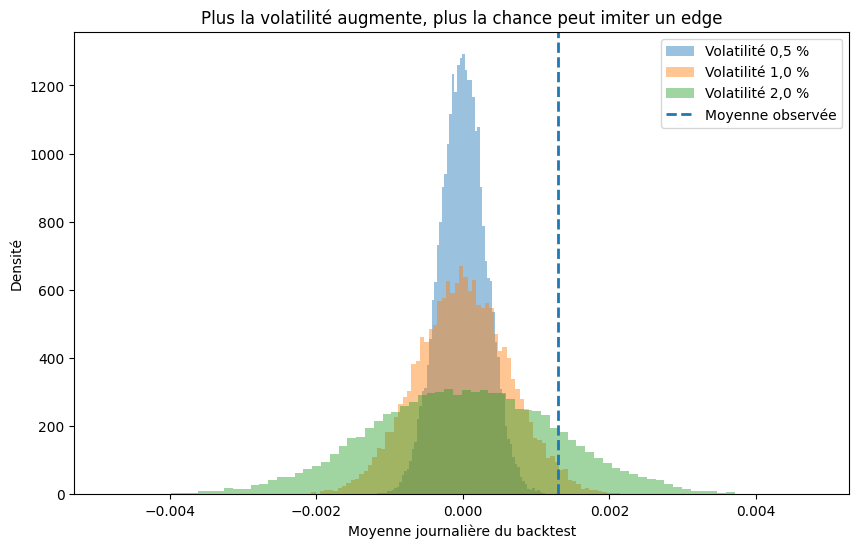

In [7]:
sample_means_low_vol = simulate_sampling_distribution(n_days=250, daily_vol=0.005)
sample_means_normal_vol = simulate_sampling_distribution(n_days=250, daily_vol=0.01)
sample_means_high_vol = simulate_sampling_distribution(n_days=250, daily_vol=0.02)

plt.figure(figsize=(10, 6))
plt.hist(sample_means_low_vol, bins=80, density=True, alpha=0.45, label="Volatilité 0,5 %")
plt.hist(sample_means_normal_vol, bins=80, density=True, alpha=0.45, label="Volatilité 1,0 %")
plt.hist(sample_means_high_vol, bins=80, density=True, alpha=0.45, label="Volatilité 2,0 %")
plt.axvline(observed_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.title("Plus la volatilité augmente, plus la chance peut imiter un edge")
plt.xlabel("Moyenne journalière du backtest")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 10. Exemple complet : diagnostic d'un signal EBTA

Créons une fonction simple pour tester un signal.

Elle prend une série de rendements de stratégie et estime la p-value par bootstrap/Monte Carlo sous $H_0$ en recentrant les rendements autour de zéro.


In [8]:
def ebta_improbability_test(strategy_returns, n_bootstrap=20_000, seed=42):
    rng = np.random.default_rng(seed)

    strategy_returns = np.asarray(strategy_returns)
    observed_mean = strategy_returns.mean()

    # Zero-centering : on impose H0 en retirant la moyenne observée
    zero_centered_returns = strategy_returns - observed_mean

    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(zero_centered_returns, size=len(zero_centered_returns), replace=True)
        bootstrap_means.append(sample.mean())

    bootstrap_means = np.array(bootstrap_means)
    p_value = np.mean(bootstrap_means >= observed_mean)

    return {
        "observed_mean": observed_mean,
        "p_value": p_value,
        "bootstrap_means": bootstrap_means
    }

## 11. Tester une stratégie fictive

On crée une stratégie avec un petit edge réel pour voir si le test arrive à distinguer le talent de la chance.


In [9]:
np.random.seed(7)

true_edge = 0.0010
strategy_returns = np.random.normal(loc=true_edge, scale=0.01, size=500)

result = ebta_improbability_test(strategy_returns)

print(f"Moyenne observée : {result['observed_mean']:.4%}")
print(f"p-value : {result['p_value']:.4f}")

if result["p_value"] < 0.05:
    print("Conclusion : résultat rare sous H0. On rejette l'hypothèse d'absence de talent.")
else:
    print("Conclusion : résultat pas assez rare. On ne rejette pas H0.")

Moyenne observée : 0.0350%
p-value : 0.2140
Conclusion : résultat pas assez rare. On ne rejette pas H0.


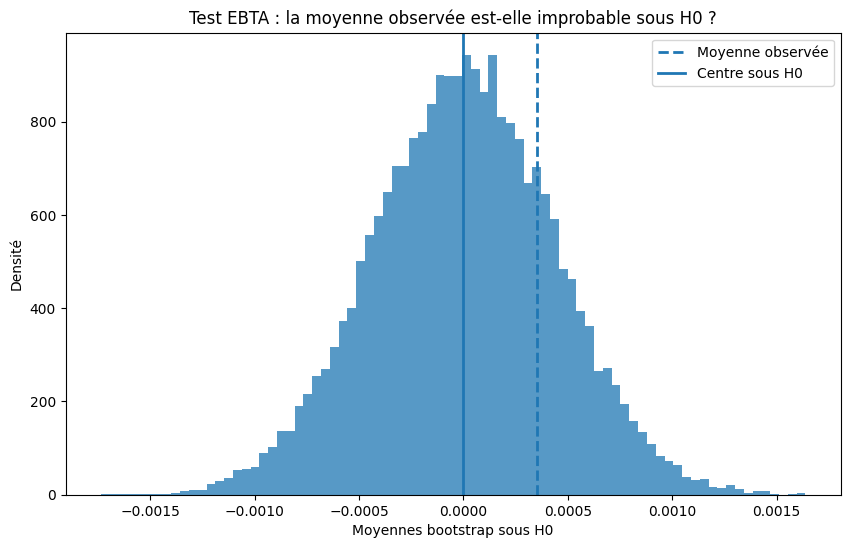

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(result["bootstrap_means"], bins=80, density=True, alpha=0.75)
plt.axvline(result["observed_mean"], linestyle="--", linewidth=2, label="Moyenne observée")
plt.axvline(0, linestyle="-", linewidth=2, label="Centre sous H0")
plt.title("Test EBTA : la moyenne observée est-elle improbable sous H0 ?")
plt.xlabel("Moyennes bootstrap sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 12. Erreur fréquente du trader

Erreur classique :

> “Ma stratégie a gagné, donc elle a un edge.”

Correction EBTA :

> “Ma stratégie a gagné. Maintenant je dois vérifier si ce gain est trop rare pour être expliqué par la chance.”

Le profit seul n'est pas une preuve.  
La preuve vient de l'improbabilité du profit sous $H_0$.


## 13. Lecture opérationnelle

Pour analyser un backtest, tu peux suivre cette grille :

| Question | Interprétation |
|---|---|
| Le rendement moyen est-il positif ? | Preuve confirmatoire minimale |
| La p-value est-elle faible ? | Le résultat est rare sous $H_0$ |
| L'échantillon est-il grand ? | Plus de puissance statistique |
| La volatilité est-elle élevée ? | La chance peut imiter plus facilement un edge |
| Les données sont-elles dé-tendancées / zero-centered selon le test ? | Le benchmark de hasard est propre |

La vraie discipline consiste à ne pas confondre **profit observé** et **edge validé**.


## 14. Résumé final

À retenir :

- Un test statistique est un **filtre contre la chance**.
- Sous $H_0$, on suppose que la règle n'a aucun talent.
- La p-value mesure la probabilité d'obtenir un résultat au moins aussi bon si $H_0$ était vraie.
- Une p-value faible signifie que la chance devient une explication peu crédible.
- Plus l'échantillon est grand, plus la distribution de la chance se resserre.
- Plus la volatilité est forte, plus la chance peut produire des résultats extrêmes.
- En EBTA, le talent n'est accepté que lorsque la chance devient une explication mathématiquement faible.

Formule mentale :

> **Edge validé = profit observé + improbabilité statistique sous l'hypothèse de hasard.**
